# SentinelIQ — 02 Isolation Forest
Train and evaluate Isolation Forest on metrics and network flow data.

In [1]:
!git clone https://github.com/hasan-rajab/SentinelIQ.git 2>/dev/null || echo "Already cloned"
import sys
sys.path.append('/kaggle/working/SentinelIQ')
%cd /kaggle/working/SentinelIQ
!pip install pyyaml joblib scikit-learn -q


/kaggle/working/SentinelIQ


In [2]:
!python data/simulated/pipeline.py --duration 120 --anomaly-rate 0.08



  SentinelIQ — Generating Training Data
  Duration: 120s | Anomaly rate: 8%

[network_simulator] Generated 2390 records.
[log_simulator] Generated 1198 records.
[NETWORK] ✅ 2390 records | 175 anomalies (7.3%) → data/simulated/network.jsonl
[LOGS   ] ✅ 1198 records | 87 anomalies (7.3%) → data/simulated/logs.jsonl
[metric_simulator] Generated 1205 records.
[METRICS] ✅ 1205 records | 90 anomalies (7.5%) → data/simulated/metrics.jsonl

  Dataset Summary

  NETWORK
    Total records : 2,390
    Anomalies     : 175
    Anomaly types : {'c2_beacon': 44, 'lateral_movement': 40, 'data_exfiltration': 34, 'dns_tunneling': 32, 'port_scan': 25}

  LOGS
    Total records : 1,198
    Anomalies     : 87
    Anomaly types : {'invalid_user': 21, 'unauthorized_access': 14, 'brute_force': 14, 'privilege_escalation': 14, 'auth_failure': 11, 'path_traversal': 6, 'web_shell': 4, 'sqli': 3}

  METRICS
    Total records : 1,205
    Anomalies     : 90
    Anomaly types : {'process_bomb': 21, 'network_exfiltra

In [3]:
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

from ml.models.isolation_forest import SentinelIsolationForest

sns.set_theme(style="darkgrid")

with open('configs/model_config.yaml') as f:
    cfg = yaml.safe_load(f)

def load_jsonl(path):
    return pd.DataFrame([json.loads(l) for l in open(path)])


## Train on Metrics

In [4]:
metrics_df = load_jsonl('data/simulated/metrics.jsonl')
feature_cols = cfg['isolation_forest']['features']
y = metrics_df['is_anomaly'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    metrics_df, y, test_size=0.2, random_state=42, stratify=y)

X_train_normal = X_train[y_train == 0]
print(f"Training on {len(X_train_normal)} normal samples")
print(f"Test set: {len(X_test)} samples | {y_test.sum()} anomalies")


Training on 892 normal samples
Test set: 241 samples | 18 anomalies


In [5]:
if_metrics = SentinelIsolationForest(config=cfg['isolation_forest'], feature_cols=feature_cols)
if_metrics.fit(X_train_normal)


[IsolationForest] Fitted on 892 samples | threshold=0.5287


In [6]:
metrics_results = if_metrics.evaluate(X_test, y_test)



[IsolationForest] Evaluation Results:
  ROC-AUC       : 0.9736
  Avg Precision : 0.7659
  Precision     : 0.5312
  Recall        : 0.9444
  F1            : 0.68
  Accuracy      : 0.9336


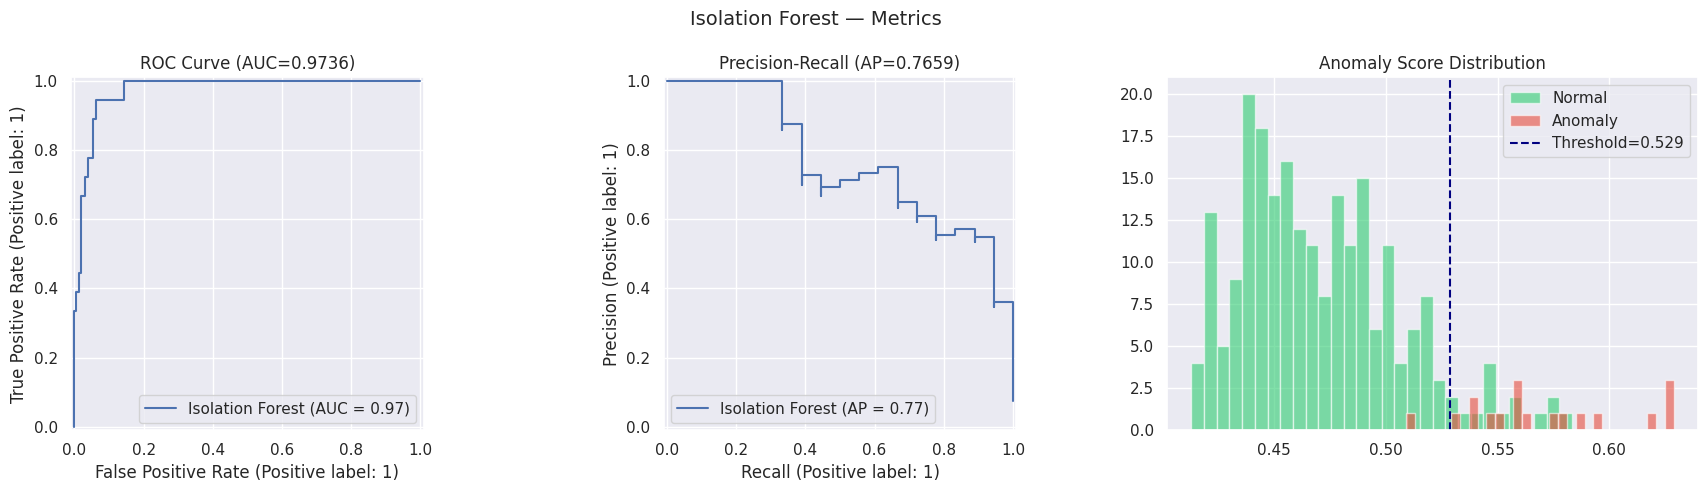

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
scores = if_metrics.score(X_test)
RocCurveDisplay.from_predictions(y_test, scores, ax=axes[0], name='Isolation Forest')
axes[0].set_title(f"ROC Curve (AUC={metrics_results['roc_auc']})")

# Precision-Recall
PrecisionRecallDisplay.from_predictions(y_test, scores, ax=axes[1], name='Isolation Forest')
axes[1].set_title(f"Precision-Recall (AP={metrics_results['avg_precision']})")

# Score distributions
normal_scores = scores[y_test == 0]
anomaly_scores = scores[y_test == 1]
axes[2].hist(normal_scores, bins=30, alpha=0.6, color='#2ecc71', label='Normal')
axes[2].hist(anomaly_scores, bins=30, alpha=0.6, color='#e74c3c', label='Anomaly')
axes[2].axvline(if_metrics.threshold, color='navy', linestyle='--', label=f'Threshold={if_metrics.threshold:.3f}')
axes[2].set_title('Anomaly Score Distribution')
axes[2].legend()

plt.suptitle('Isolation Forest — Metrics', fontsize=14)
plt.tight_layout()
plt.show()


## Train on Network Flows

In [8]:
network_df = load_jsonl('data/simulated/network.jsonl')
net_features = cfg['network']['features']
y_net = network_df['is_anomaly'].astype(int).values

X_train_net, X_test_net, y_train_net, y_test_net = train_test_split(
    network_df, y_net, test_size=0.2, random_state=42, stratify=y_net)

X_train_net_normal = X_train_net[y_train_net == 0]

network_cfg = {**cfg['isolation_forest'], **cfg['network']}
if_network = SentinelIsolationForest(config=network_cfg, feature_cols=net_features)
if_network.fit(X_train_net_normal)
network_results = if_network.evaluate(X_test_net, y_test_net)


[IsolationForest] Fitted on 1772 samples | threshold=0.5602

[IsolationForest] Evaluation Results:
  ROC-AUC       : 0.8213
  Avg Precision : 0.4303
  Precision     : 0.3509
  Recall        : 0.5714
  F1            : 0.4348
  Accuracy      : 0.8912


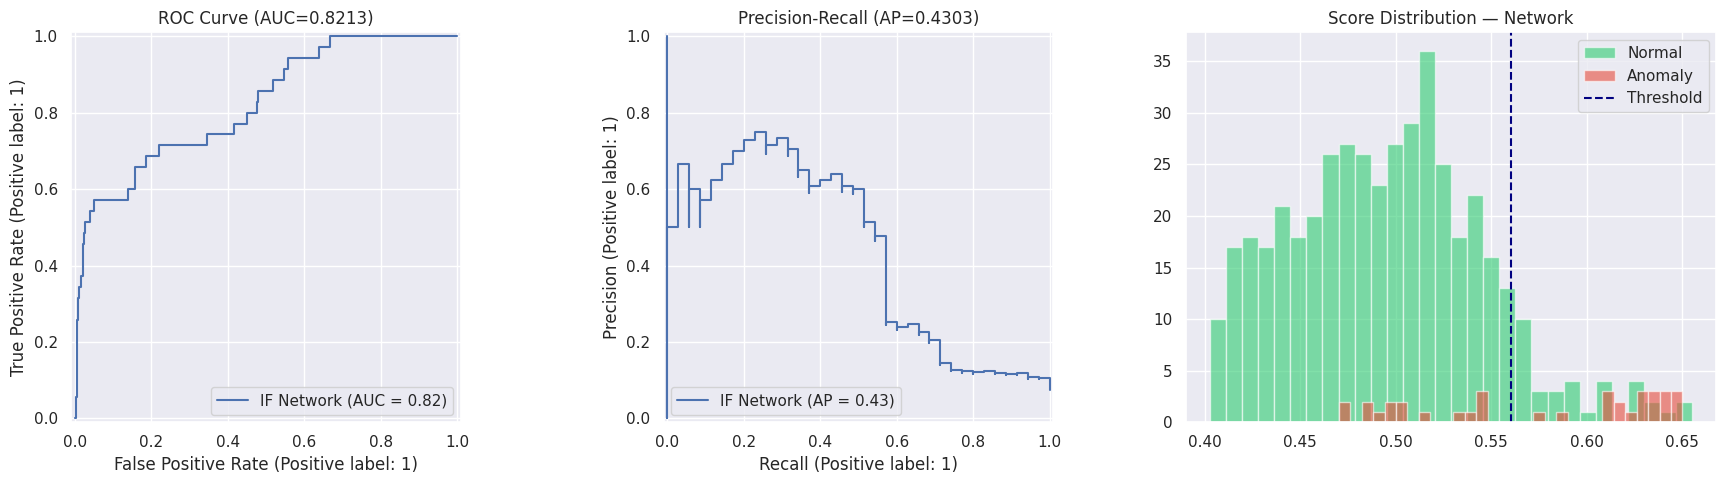

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

net_scores = if_network.score(X_test_net)
RocCurveDisplay.from_predictions(y_test_net, net_scores, ax=axes[0], name='IF Network')
axes[0].set_title(f"ROC Curve (AUC={network_results['roc_auc']})")

PrecisionRecallDisplay.from_predictions(y_test_net, net_scores, ax=axes[1], name='IF Network')
axes[1].set_title(f"Precision-Recall (AP={network_results['avg_precision']})")

axes[2].hist(net_scores[y_test_net==0], bins=30, alpha=0.6, color='#2ecc71', label='Normal')
axes[2].hist(net_scores[y_test_net==1], bins=30, alpha=0.6, color='#e74c3c', label='Anomaly')
axes[2].axvline(if_network.threshold, color='navy', linestyle='--', label=f'Threshold')
axes[2].set_title('Score Distribution — Network')
axes[2].legend()

plt.tight_layout()
plt.show()


## Save Models

In [10]:
import os
os.makedirs('ml/saved_models', exist_ok=True)
if_metrics.save('ml/saved_models', name='isolation_forest_metrics')
if_network.save('ml/saved_models', name='isolation_forest_network')
print("Models saved.")


[IsolationForest] Saved to ml/saved_models/isolation_forest_metrics_*
[IsolationForest] Saved to ml/saved_models/isolation_forest_network_*
Models saved.


## Results Summary

In [11]:
summary = pd.DataFrame([
    {'Model': 'IF Metrics', **{k:v for k,v in metrics_results.items() if k != 'confusion_matrix'}},
    {'Model': 'IF Network', **{k:v for k,v in network_results.items() if k != 'confusion_matrix'}},
])
print(summary[['Model','roc_auc','avg_precision','precision','recall','f1','accuracy']].to_string(index=False))


     Model  roc_auc  avg_precision  precision  recall     f1  accuracy
IF Metrics   0.9736         0.7659     0.5312  0.9444 0.6800    0.9336
IF Network   0.8213         0.4303     0.3509  0.5714 0.4348    0.8912
